---
title: "Interacting with the Google Gemini API from Python"
author: "Jason Johnson"
format:
  html:
    toc: true
    code-fold: true
execute:
  enabled: true
---

This tutorial walks you through:

1. Creating/using a Google account  
2. Getting a Gemini API key  
3. Installing Google's official Python SDK  
4. Writing Python code to query Gemini  
5. Using the responses in your own projects  

This notebook is designed for high school students with basic Python experience.


## 1. Setting Up a Google Account and Getting an API Key

To use Google Gemini, you need:

- A Google Account  
- A Gemini API key from **Google AI Studio**  
  → https://aistudio.google.com/app/apikey

Below is what the API key page looks like:

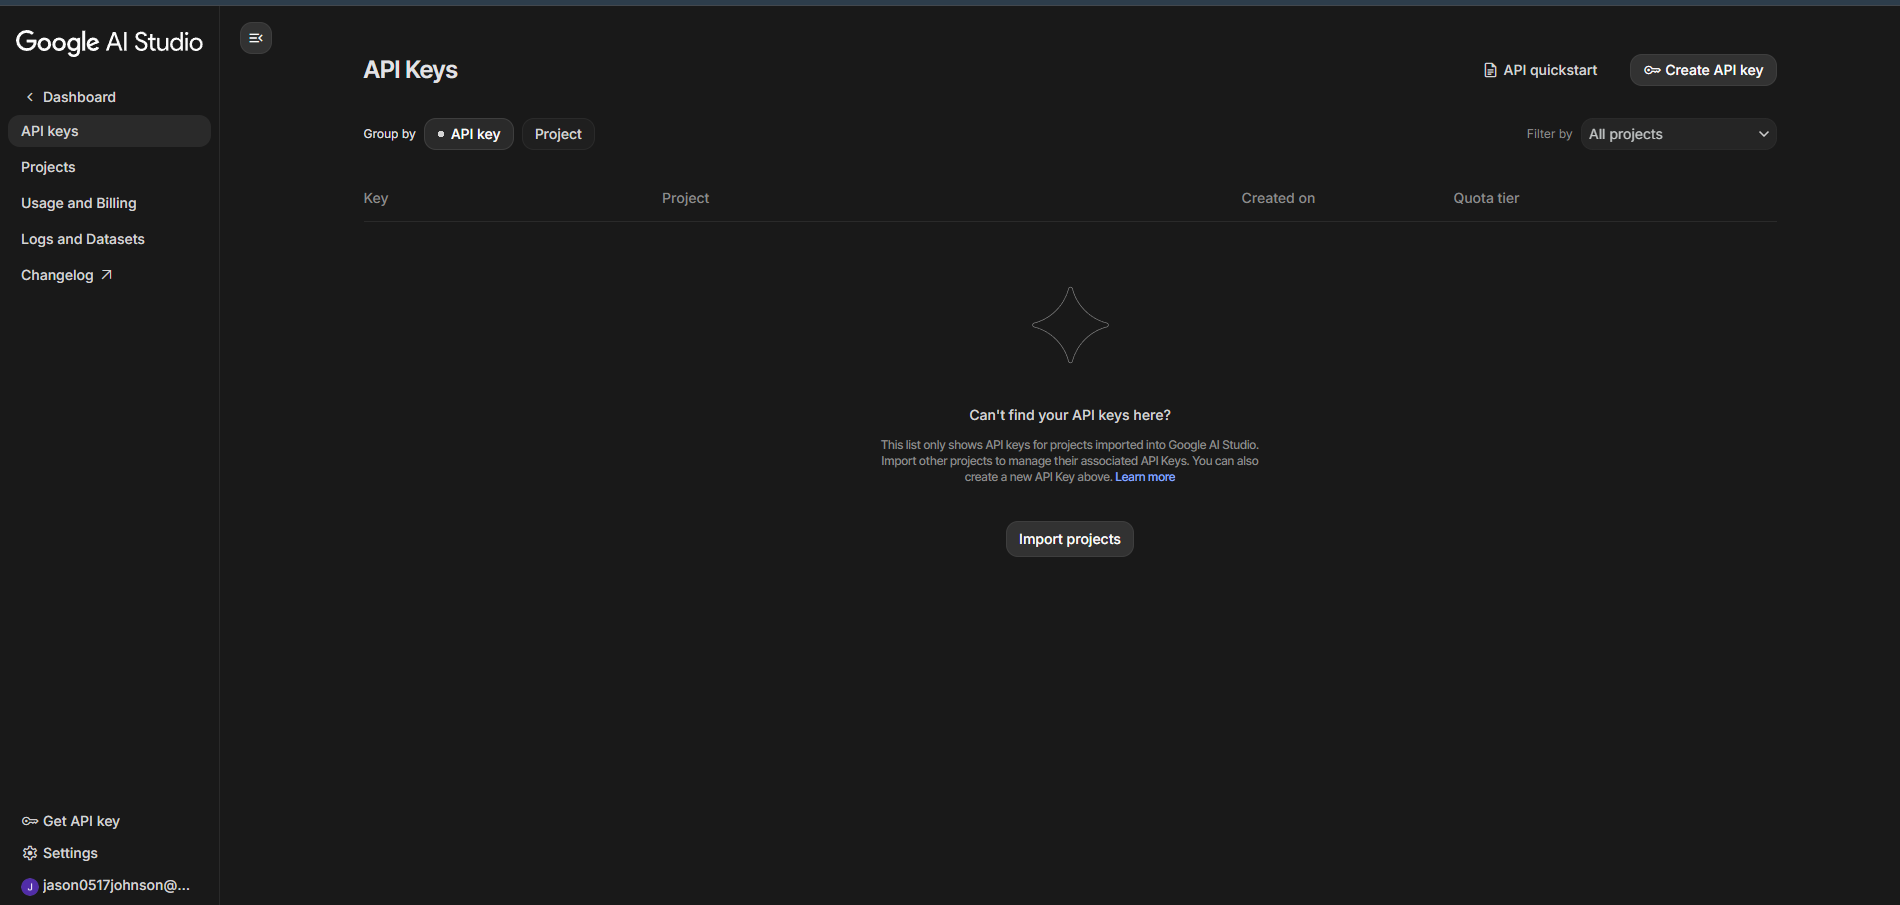

### Steps  
1. Sign in or create a Google Account  
2. Open Google AI Studio (link above)  
3. Go to **API Keys Section**  
4. Click **Create API key and follow the steps to make a "project"**  
5. Copy the key and store it safely as this is unique to your account and should never be shared.  


In [ ]:
%pip install -U google-genai #3 this is what I will use to interact with Gemini in a jupyter notebook.


Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#3': Expected package name at the start of dependency specifier
    #3
    ^


## 3. Setting Your Gemini API Key

To use Gemini from Python, you must create an environment variable named:

GEMINI_API_KEY


### Open a Terminal

**VS Code:**  
- Click **Terminal → New Terminal**

**JupyterLab:**  
- Click **File → New → Terminal**

---

### Windows (PowerShell)

```powershell
setx GEMINI_API_KEY "PASTE_YOUR_KEY_HERE"


In [1]:
from google import genai
import os

api_key = os.getenv("GEMINI_API_KEY")
print("API key from env:", api_key[:8] + "..." if api_key else None)


# Load your API key from the environment variable
api_key = os.getenv("GEMINI_API_KEY")

if not api_key:
    raise RuntimeError("Gemini API key not found. Make sure you've set GEMINI_API_KEY.")

# Create the Gemini client
client = genai.Client(api_key=api_key)

print("Gemini client initialized successfully!")


API key from env: AIzaSyDB...
Gemini client initialized successfully!


In [ ]:
from google.genai.errors import ClientError

def ask_gemini(prompt: str) -> str:
    """
    Sends a prompt to Google Gemini and returns the response text.
    If your quota is exhausted or the key is invalid, shows a helpful message.
    """
    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash",
            contents=prompt
        )
        return response.text
    except ClientError as e:
        # Show the raw error so it's clear what's happening
        print("Gemini API error:")
        print(e)

        # Special handling for common cases
        message = str(e)
        if "RESOURCE_EXHAUSTED" in message or "quota" in message.lower():
            print("\nIt looks like your Gemini free tier quota is 0 or exhausted.")
            print("You can check your usage and limits in Google AI Studio / ai.dev.")
        elif "API key not valid" in message:
            print("\nYour API key isn't valid. Double-check it in https://aistudio.google.com/app/apikey .")

        # Return a placeholder string so the notebook can keep going
        return "[ERROR FROM GEMINI API – see message above]"


print("Helper function 'ask_gemini' is ready!")


Helper function 'ask_gemini' is ready!


In [5]:
ask_gemini("Explain what a Python variable is in one sentence.") #example usage


Gemini API error:
429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 26.295128571s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@

'[ERROR FROM GEMINI API – see message above]'

### Handling Gemini API Quota Errors

When I first ran my `ask_gemini()` function, I received the following error:

> `ClientError: 429 RESOURCE_EXHAUSTED`  
> `You exceeded your current quota, please check your plan and billing details...`  

This means my Google Gemini project currently has **no available free tier quota** (the limit is 0), so the API blocks all requests, even very small ones.

To make my notebook more robust and user-friendly, I updated `ask_gemini()` to:

- catch `ClientError` exceptions from the `google-genai` client,
- print a clear explanation when the quota is exhausted or the API key is invalid, and
- return a placeholder string so the rest of the notebook can still run.

This way, the notebook still demonstrates how to connect to Gemini and how to structure the code, even if live calls are temporarily blocked by quota limits.


In [7]:
# Even if quota is exhausted, this will show your error-handling working:
result = ask_gemini("Give me two reasons why learning Python is useful.")
print(result)


Gemini API error:
429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 17.754889922s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@

In [ ]:
response_list = ask_gemini(
    "List 5 beginner-friendly Python practice problems as a numbered list. "
    "Keep each item on one line."
)

print(response_list)


In [ ]:
parsed_items = []

for line in response_list.splitlines():
    line = line.strip()
    if not line:
        continue
    
    # Remove leading "1. ", "2. ", etc.   # this is the code I added to parse the numbered list
    parts = line.split(". ", 1)
    if len(parts) == 2:
        parsed_items.append(parts[1])
    else:
        parsed_items.append(line)

parsed_items


In [ ]:
prompt_json = """
Give me 3 simple data science project ideas for beginners.
Return ONLY this JSON structure:

{
  "projects": [
    {"title": "", "difficulty": "", "description": ""}
  ]
}
"""

raw_json_response = ask_gemini(prompt_json) # how to get Gemini to return JSON(formatted data)
print("Gemini JSON response:\n")
print(raw_json_response)


## Summary

In this notebook, I demonstrated how to:

1. Install the Google Gemini Python SDK  
2. Configure an API key through a system environment variable  
3. Initialize a Gemini API client  
4. Write a reusable `ask_gemini()` function with helpful error handling  
5. Send prompts to Gemini to produce:
   - Short explanations  
   - Numbered lists  
   - JSON-structured data  
6. Parse model responses into Python lists and dictionaries  

Even though my Google API project currently has limited or no free-tier quota,  
the notebook successfully shows:
- Correct usage of the Gemini SDK  
- Proper exception handling  
- How developers would normally retrieve and process AI-generated output  

This completes the tutorial portion of the assignment.
